<a href="https://colab.research.google.com/github/JosegregTovar/GOOGLE-COLLAB/blob/main/Actividad7PCA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 7**
Análisis de Componentes Principales (PCA)

---

### **Integrantes:**

*   NOMBRE: JOSEGREG DE JESUS TOVAR BLANCO
*   MATRÍCULA: A01840476
* NOMBRE: Adrian Valdes Zavala
* MATRÍCULA: A01720439
* NOMBRE: Oscar Alfonso Valenzuela Muñoz
* MATRICULA: A01840486
* NOMBRE: Sebastian Valencia Aguirre
* MATRICULA: A01364876


En esta actividad trabajarás con el archivo `automobile_dataset.csv`, basado en un conjunto de datos sobre características técnicas y especificaciones de automóviles, disponible en el repositorio UCI Machine Learning.

Los datos fueron recopilados para analizar diferentes aspectos de los vehículos y sus precios, e incluyen información sobre el fabricante, tipo de motor, dimensiones, peso, rendimiento de combustible y otras especificaciones técnicas. Los indicadores incluidos son:

* `symboling`: Nivel de riesgo del seguro del automóvil, de -3 (bajo riesgo) a +3 (alto riesgo)
* `normalized_losses`: Pérdidas normalizadas del seguro (valor numérico de la aseguradora, algunas veces faltante)
* `make`: Marca del automóvil (por ejemplo, Audi, BMW, Honda)
* `fuel_type`: Tipo de combustible (gasolina o diésel)
* `aspiration`: Tipo de aspiración del motor (normal o turbo)
* `num_doors`: Número de puertas del automóvil (dos o cuatro)
* `body_style`: Estilo de carrocería (sedán, hatchback, wagon, hardtop, convertible)
* `drive_wheels`: Tipo de tracción (fwd: delantera, rwd: trasera, 4wd: en las cuatro ruedas)
* `engine_location`: Ubicación del motor (delantero o trasero)
* `wheel_base`: Distancia entre ejes (en pulgadas)
* `length`: Largo total del automóvil (en pulgadas)
* `width`: Ancho total del automóvil (en pulgadas)
* `height`: Altura total del automóvil (en pulgadas)
* `curb_weight`: Peso del automóvil sin carga (en libras)
* `engine_type`: Tipo de motor (OHV, OHC, DOHC, etc.)
* `num_cylinders`: Número de cilindros del motor
* `engine_size`: Tamaño del motor (en cc)
* `fuel_system`: Sistema de combustible (por ejemplo, mpfi, 2bbl, 4bbl)
* `bore`: Diámetro del cilindro (en pulgadas)
* `stroke`: Carrera del pistón (en pulgadas)
* `compression_ratio`: Relación de compresión del motor
* `horsepower`: Potencia del motor (en caballos de fuerza)
* `peak_rpm`: Revoluciones máximas por minuto
* `city_mpg`: Rendimiento de combustible en ciudad (millas por galón)
* `highway_mpg`: Rendimiento de combustible en carretera (millas por galón)
* `price`: Precio del automóvil (en dólares estadounidenses) Es la variable de salida o *target*, es decir, la que se pretende predecir más adelante al construir el modelo.

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.

In [1]:
# Importar las bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
#Extras
from IPython.display import display
import math

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


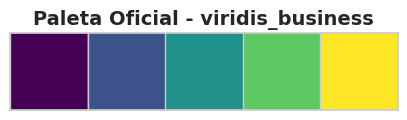

In [3]:

# PALETA OFICIAL DEL PROYECTO

import matplotlib.pyplot as plt
import seaborn as sns

# Paleta personalizada inspirada en viridis
viridis_business = [
    "#440154",  # Morado
    "#3b528b",  # Azul
    "#21918c",  # Turquesa
    "#5ec962",  # Verde
    "#fde725"   # Amarillo
]

# Aplicamos estilo profesional
sns.set_theme(style="whitegrid")

# Configuración global de matplotlib
plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "axes.titleweight": "bold"
})

# Visualizamos la paleta
sns.palplot(viridis_business)
plt.title("Paleta Oficial - viridis_business")
plt.show()

1. Descarga el archivo: `automobile_dataset.csv` y guarda, en un dataframe (`cars_df`), todos sus registros.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?
* Al revisar los primeros registros, notarás que la columna `normalized_losses` contiene el símbolo `?`. Esto sugiere que se utilizó para indicar valores faltantes. Identifica todas las columnas que presentan este símbolo.
* Sustituye el símbolo `?` por valores faltantes (`NaN`) y convierte las columnas al tipo de dato adecuado. Esto es necesario porque la presencia del símbolo pudo haber hecho que pandas las interpretara como object, aunque en realidad no lo fueran.

In [4]:
cars_df = pd.read_csv("/content/drive/MyDrive/01 Analisis de Datos/ACTIVIDAD 7/automobile_dataset.csv")

# Vemos tamaño (filas, columnas) para confirmar que cargó todo
cars_df.shape

# Opcional: vistazo rápido a los primeros registros
cars_df.head()

,symboling,normalized_losses,make,fuel_type,aspiration,num_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


In [5]:
# Resumen general del dataset (tipos de datos y no-null)
cars_df.info()

# Contamos columnas numéricas vs texto (object)
num_cols = cars_df.select_dtypes(include=["int64", "float64"]).columns
text_cols = cars_df.select_dtypes(include=["object"]).columns

print(f"\n Columnas numéricas: {len(num_cols)}")
print(f"Columnas de texto (object): {len(text_cols)}")

# Ver cuales son
display(num_cols)
print("\n")
display(text_cols)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized_losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel_type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num_doors          205 non-null    object 
 6   body_style         205 non-null    object 
 7   drive_wheels       205 non-null    object 
 8   engine_location    205 non-null    object 
 9   wheel_base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb_weight        205 non-null    int64  
 14  engine_type        205 non-null    object 
 15  num_cylinders      205 non-null    int64  
 16  engine_size        205 non

Index(['symboling', 'wheel_base', 'length', 'width', 'height', 'curb_weight',
       'num_cylinders', 'engine_size', 'compression_ratio', 'city_mpg',
       'highway_mpg'],
      dtype='object')

Index(['normalized_losses', 'make', 'fuel_type', 'aspiration', 'num_doors',
       'body_style', 'drive_wheels', 'engine_location', 'engine_type',
       'fuel_system', 'bore', 'stroke', 'horsepower', 'peak_rpm', 'price'],
      dtype='object')

In [6]:
# Identificamos columnas que contienen el símbolo '?'
cols_with_question = [
    col for col in cars_df.columns
    if (cars_df[col].astype(str) == "?").any()
]

cols_question_df = pd.DataFrame({
    "Columnas con '?'": cols_with_question
})

display(cols_question_df)
display(f"Total: {len(cols_question_df)}")

,Columnas con '?'
0,normalized_losses
1,bore
2,stroke
3,horsepower
4,peak_rpm
5,price


'Total: 6'

In [7]:
# Sustituimos '?' por NaN en todo el dataframe
cars_df = cars_df.replace("?", np.nan)

In [8]:
# Intentamos convertir a numericas las columnas object que realmente son numeros disfrazados

for col in cars_df.select_dtypes(include="object").columns:
    converted = pd.to_numeric(cars_df[col], errors="coerce")

    # Si al convertir NO queda todo NaN, es señal de que si había números reales
    # (es decir, la columna probablemente debe ser numérica)
    if converted.notna().sum() > 0:
        # Regla práctica: si al menos 80% de los valores NO nulos se pueden volver número,
        # entonces hacemos la conversión definitiva.
        non_null_original = cars_df[col].notna().sum()
        if non_null_original > 0:
            ratio_convertible = converted.notna().sum() / non_null_original
            if ratio_convertible >= 0.80:
                cars_df[col] = converted  # convertimos la columna

# Revisamos nuevamente tipos tras las conversiones
cars_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized_losses  164 non-null    float64
 2   make               205 non-null    object 
 3   fuel_type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num_doors          205 non-null    object 
 6   body_style         205 non-null    object 
 7   drive_wheels       205 non-null    object 
 8   engine_location    205 non-null    object 
 9   wheel_base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  curb_weight        205 non-null    int64  
 14  engine_type        205 non-null    object 
 15  num_cylinders      205 non-null    int64  
 16  engine_size        205 non

In [9]:
# Confirmacion de que ya no debe existir el símbolo '?'
has_question = (cars_df.astype(str) == "?").any().any()
print("¿Aún existe '?' en el dataframe?:", has_question)

¿Aún existe '?' en el dataframe?: False


# Análisis exploratorio de datos (univariado)

2. Antes de iniciar con el análisis univariado, verifica si hay valores duplicados e imprime el porcentaje de faltantes por columna.
* Obtén las estadísticas descriptivas, separado las numéricas (incluye asimetría y curtosis) y las categóricas (incluye tablas de frecuencias).
* Genera histogramas para las numéricas y diagramas de barras para las categóricas.

In [10]:
# Numero de registros duplicados
duplicates = cars_df.duplicated().sum()

display(f"Cantidad de registros duplicados: {duplicates}")

display(cars_df[cars_df.duplicated()])

'Cantidad de registros duplicados: 0'

,symboling,normalized_losses,make,fuel_type,aspiration,num_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price


**No hay valores duplicados.**

In [11]:
# Porcentaje de valores faltantes

falta_percentage = (
    cars_df.isna()
    .mean() * 100
).sort_values(ascending=False)

missing_df = pd.DataFrame({
    "Porcentaje de Faltantes (%)": falta_percentage
})

display(missing_df)

,Porcentaje de Faltantes (%)
normalized_losses,20.00000
stroke,1.95122
price,1.95122
bore,1.95122
horsepower,0.97561
peak_rpm,0.97561
make,0.00000
fuel_type,0.00000
aspiration,0.00000
symboling,0.00000


## **Análisis Variables Numéricas.**

In [12]:
# Estadísticas descriptivas - Numéricas


num_cols = cars_df.select_dtypes(include=["int64", "float64"]).columns

num_stats = cars_df[num_cols].describe().T

# Agregamos asimetría y curtosis
num_stats["skewness"] = cars_df[num_cols].skew()
num_stats["kurtosis"] = cars_df[num_cols].kurt()

display(num_stats)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
symboling,205.0,0.834146,1.245307,-2.00,0.00,1.00,2.00,3.00,0.211072,-0.676271
normalized_losses,164.0,122.000000,35.442168,65.00,94.00,115.00,150.00,256.00,0.765976,0.525440
wheel_base,205.0,98.756585,6.021776,86.60,94.50,97.00,102.40,120.90,1.050214,1.017039
length,205.0,174.049268,12.337289,141.10,166.30,173.20,183.10,208.10,0.155954,-0.082895
width,205.0,65.907805,2.145204,60.30,64.10,65.50,66.90,72.30,0.904003,0.702764
height,205.0,53.724878,2.443522,47.80,52.00,54.10,55.50,59.80,0.063123,-0.443812
curb_weight,205.0,2555.565854,520.680204,1488.00,2145.00,2414.00,2935.00,4066.00,0.681398,-0.042854
num_cylinders,205.0,4.380488,1.080854,2.00,4.00,4.00,4.00,12.00,2.817459,13.714866
engine_size,205.0,126.907317,41.642693,61.00,97.00,120.00,141.00,326.00,1.947655,5.305682
bore,201.0,3.329751,0.273539,2.54,3.15,3.31,3.59,3.94,0.020016,-0.828945


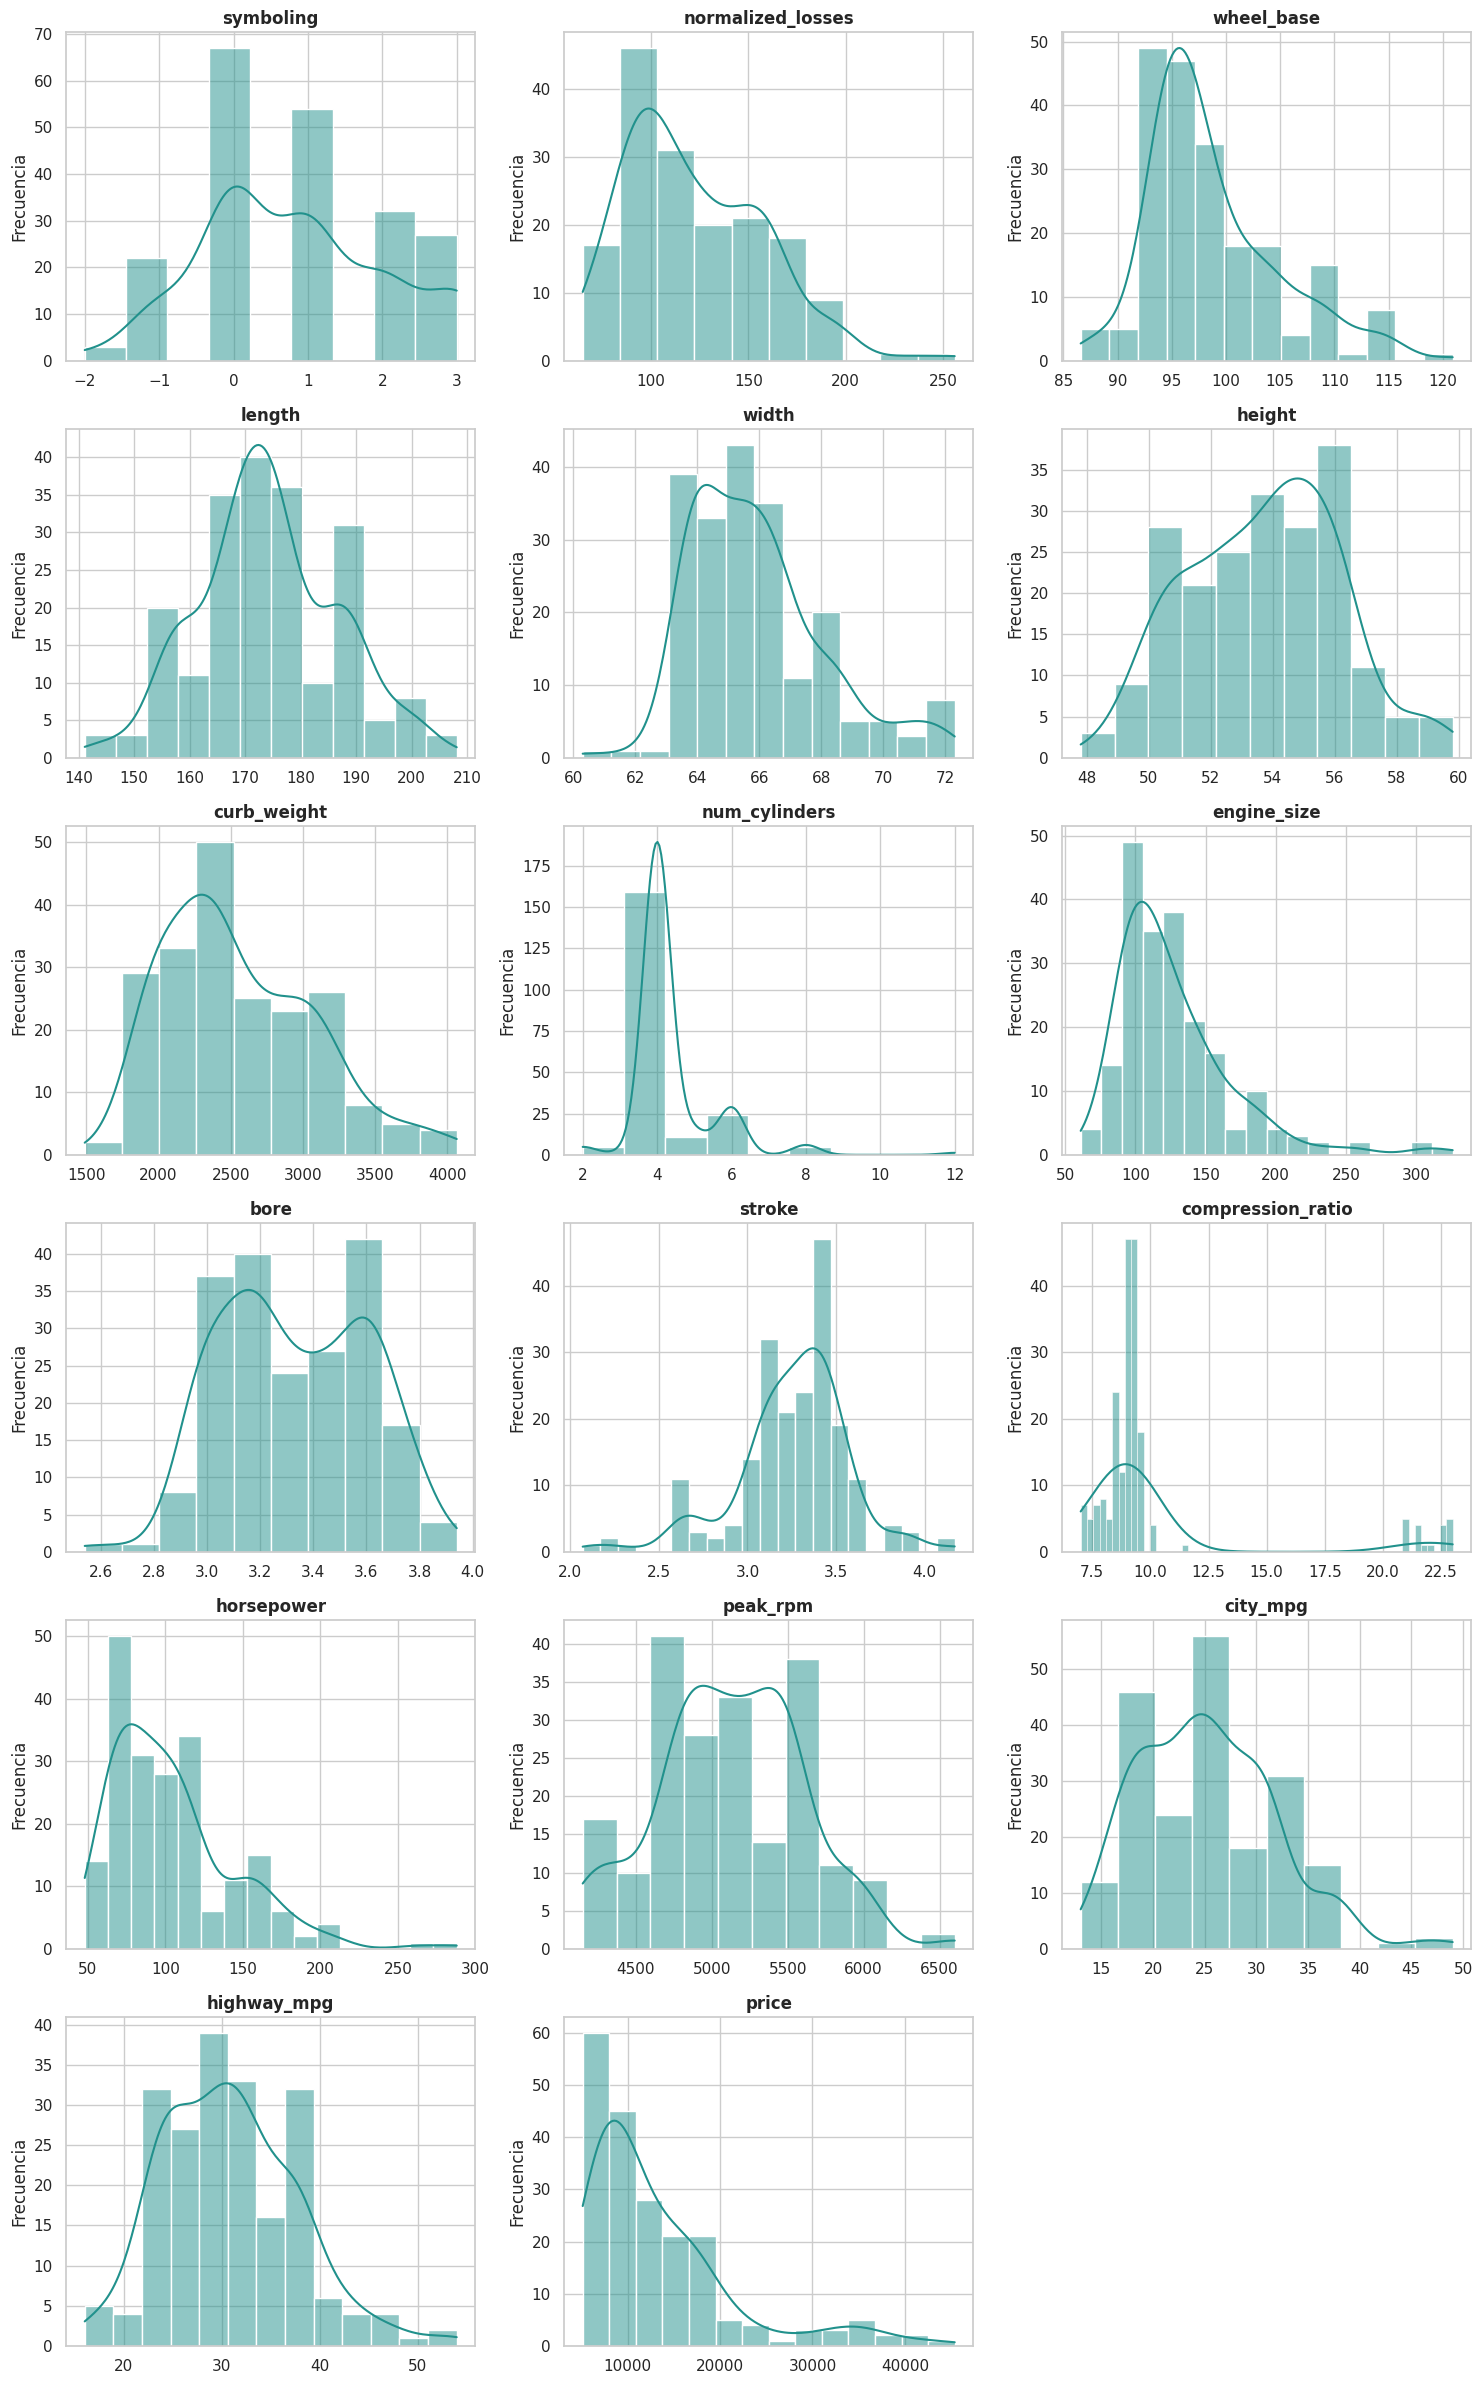

In [13]:
# Histogramas con subplots

# Número de columnas en el grid
n_cols = 3

# Número total de variables numéricas
n_vars = len(num_cols)

# Calculamos número de filas necesarias
n_rows = math.ceil(n_vars / n_cols)

# Creamos figura con subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))

# Convertimos axes en array plano (por si es 1 sola fila)
axes = axes.flatten()

for i, col in enumerate(num_cols):

    sns.histplot(
        cars_df[col],
        kde=True,
        color=viridis_business[2],
        ax=axes[i]
    )

    axes[i].set_title(f"{col}", fontsize=12, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frecuencia")

# Eliminamos ejes vacíos si existen
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

## **Análisis Variables Categóricas**

In [14]:
# Estadísticas descriptivas - Categóricas

cat_cols = cars_df.select_dtypes(include=["object", "category"]).columns

for col in cat_cols:

    display(f"Frecuencia de {col}")

    freq_table = (
        cars_df[col]
        .value_counts(dropna=False)
        .head(10)
        .reset_index()
    )

    freq_table.columns = [col, "Frecuencia"]

    display(freq_table)
    print("\n")


'Frecuencia de make'

,make,Frecuencia
0,toyota,32
1,nissan,18
2,mazda,17
3,mitsubishi,13
4,honda,13
5,subaru,12
6,volkswagen,12
7,volvo,11
8,peugot,11
9,dodge,9


'Frecuencia de fuel_type'

,fuel_type,Frecuencia
0,gas,185
1,diesel,20


'Frecuencia de aspiration'

...

,engine_location,Frecuencia
0,front,202
1,rear,3


'Frecuencia de engine_type'

,engine_type,Frecuencia
0,ohc,148
1,ohcf,15
2,ohcv,13
3,dohc,12
4,l,12
5,rotor,4
6,dohcv,1


'Frecuencia de fuel_system'

,fuel_system,Frecuencia
0,mpfi,94
1,2bbl,66
2,idi,20
3,1bbl,11
4,spdi,9
5,4bbl,3
6,mfi,1
7,spfi,1


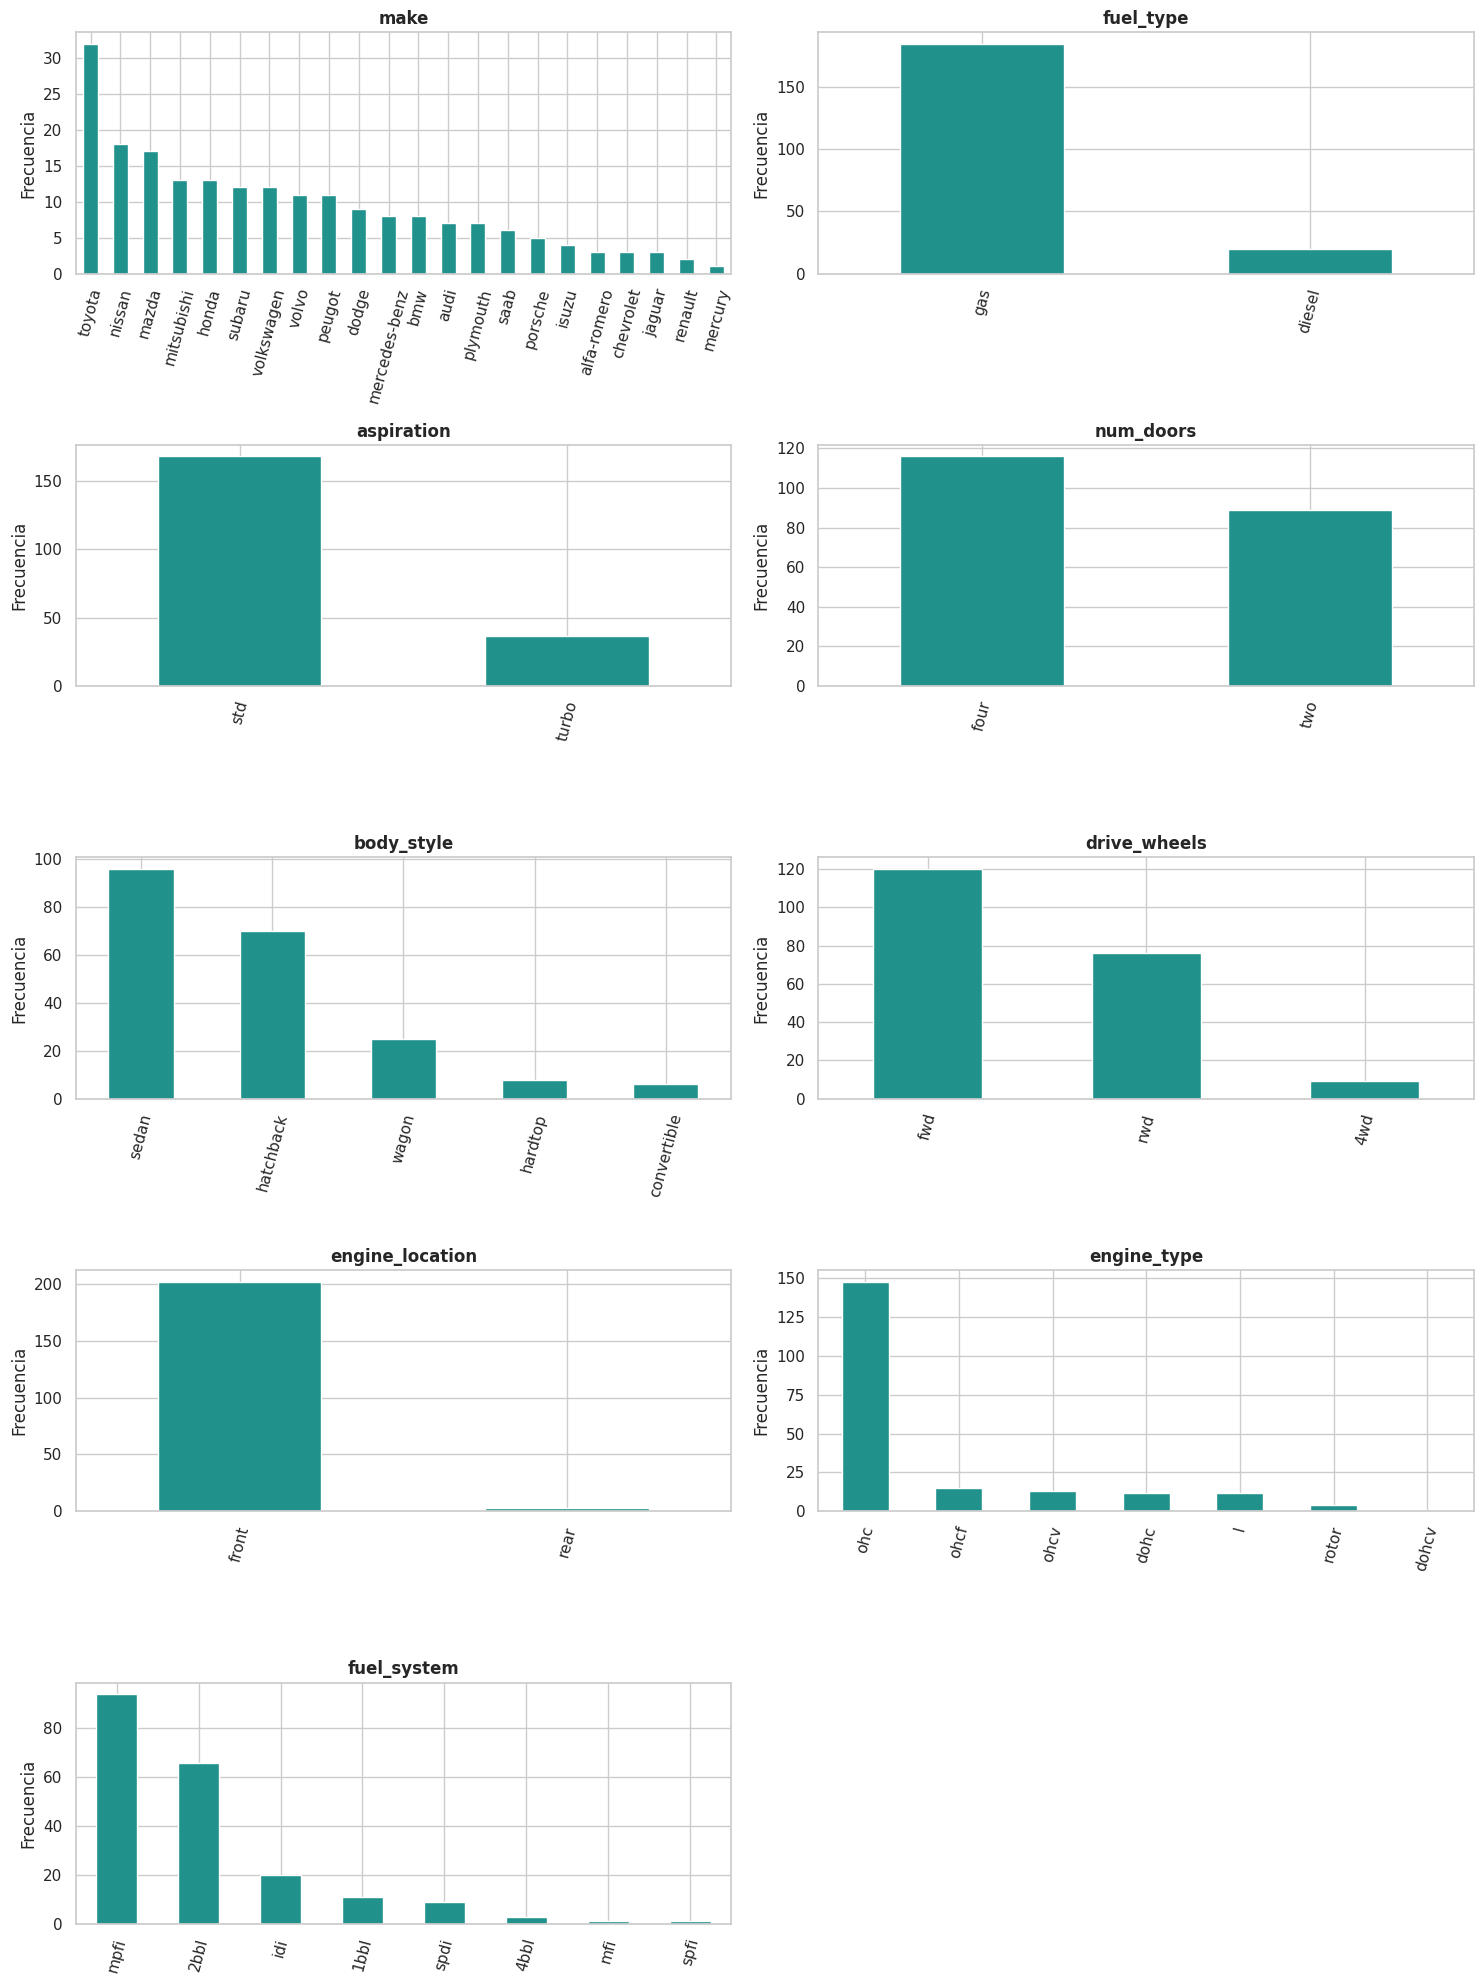

In [15]:
# Diagramas de barras con subplots

# Número de columnas del grid
n_cols = 2
n_vars = len(cat_cols)
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_cols):

    cars_df[col].value_counts().plot(
        kind="bar",
        color=viridis_business[2],
        ax=axes[i]
    )

    axes[i].set_title(f"{col}", fontsize=12, fontweight="bold")
    axes[i].set_xlabel("")
    axes[i].set_ylabel("Frecuencia")
    axes[i].tick_params(axis='x', rotation=75)

# Eliminamos ejes vacíos si existen
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

# Análisis exploratorio de datos (bivariado)

3. Genera algunos gráficos bivariados para familiarizarte con el conjunto de datos:
* Gráfico de barras apiladas normalizadas que muestra la distribución de los tipos de tracción para cada fabricante.
* Diagrama de cajas para visualizar cómo se distribuye el precio de los automóviles según el estilo de carrocería. Esto permitirá comparar la mediana, los cuartiles y la presencia de valores atípicos entre los diferentes tipos de carrocería.
* Gráfico de barras que muestre los 10 automóviles más caros, ordenados de mayor a menor precio, con cada barra diferenciada por fabricante.
* Diagrama de dispersión para explorar la relación entre el tamaño del motor y el precio de los automóviles. Diferencia con colores los puntos según el tipo de aspiración y con el tamaño de los puntos el número de puertas.

**Nota.** Debes incluir en cada gráfico una conclusión de lo observado.

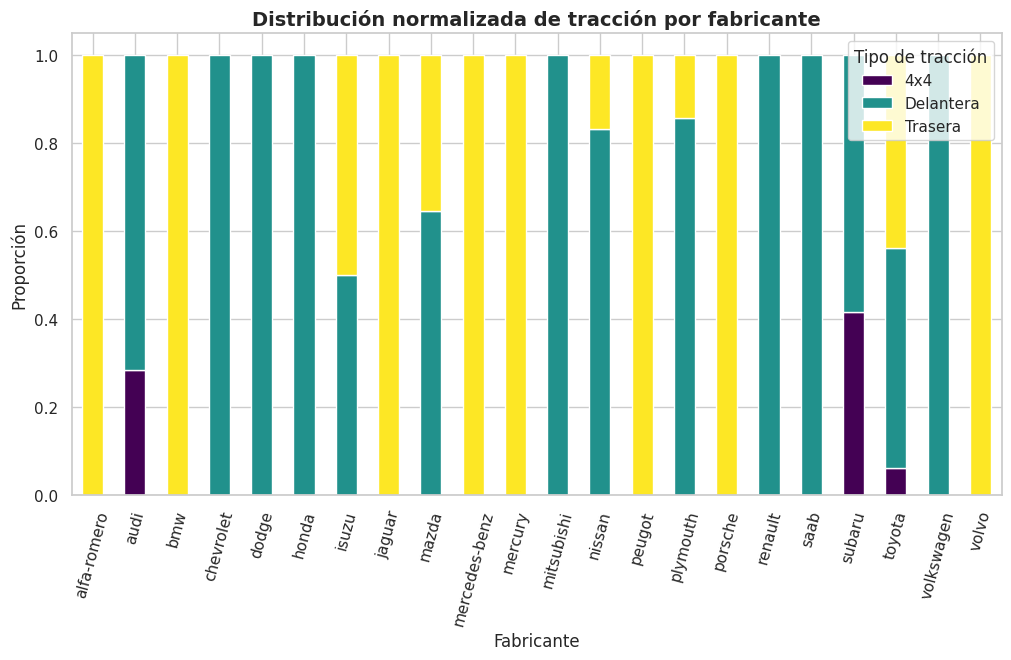

In [17]:

# 3.1 Barras apiladas normalizadas
# Tipo de tracción por fabricante

# Tabla cruzada normalizada por fabricante
tabla_traccion = pd.crosstab(
    cars_df["make"],          # Fabricante
    cars_df["drive_wheels"],  # Tipo de traccion
    normalize="index"         # Normaliza por fila
)

# Diccionario para categorías
mapa_traccion = {
    "fwd": "Delantera",
    "rwd": "Trasera",
    "4wd": "4x4"
}

# Renombramos columnas de la tabla (no el dataframe original)
tabla_traccion = tabla_traccion.rename(columns=mapa_traccion)

# Ordenamos fabricantes alfabeticamente
tabla_traccion = tabla_traccion.sort_index()

# Grafico
tabla_traccion.plot(
    kind="bar",
    stacked=True,
    colormap="viridis",
    figsize=(12,6)
)

plt.title("Distribución normalizada de tracción por fabricante")
plt.ylabel("Proporción")
plt.xlabel("Fabricante")
plt.xticks(rotation=75)
plt.legend(title="Tipo de tracción")
plt.show()

**Análisis:**

Desde el análisis de datos, la gráfica muestra una alta concentración de tracción delantera y trasera según fabricante, con muy baja presencia relativa de tracción 4x4 en la mayoría de las marcas. Se observa que varios fabricantes presentan distribuciones casi determinísticas (proporción cercana a 1 en una sola categoría), lo que indica baja diversidad interna en el tipo de tracción dentro de ciertas marcas. Esto sugiere que el tipo de tracción no está distribuido aleatoriamente en el dataset, sino que depende fuertemente del fabricante, lo que implica una relación categorica entre ambas variables.

 Estos patrones son coherentes con la especialización de mercado de las marcas: fabricantes como Porsche o Jaguar tienden a asociarse con tracción trasera (por ser deportivos) mientras que marcas de consumo masivo tienden a usar tracción delantera por eficiencia y costos. La baja presencia de 4x4 también es consistente con que el dataset parece que se centra mas en autos de calle que en SUV o vehículos todoterreno.

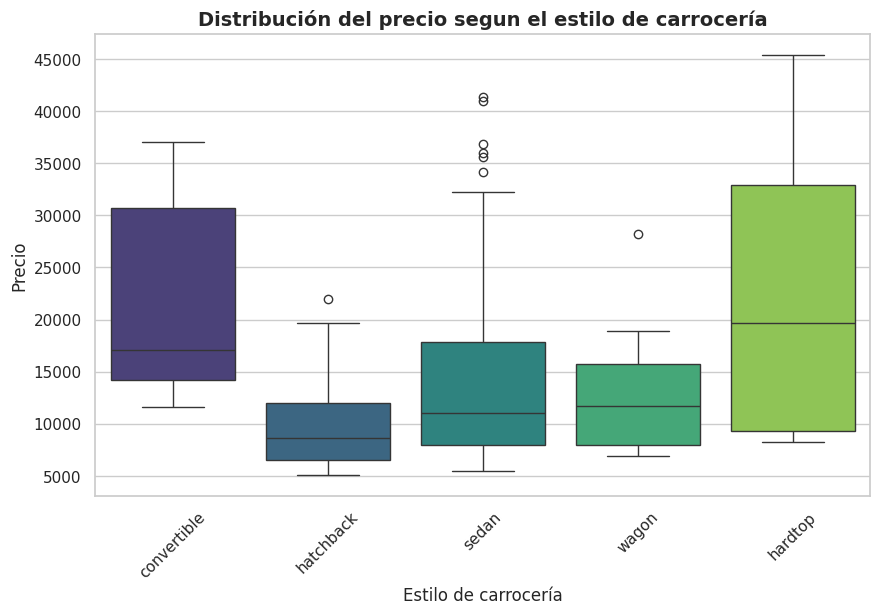

In [18]:
# 3.2 Boxplot: Precio vs estilo carrocería

plt.figure(figsize=(10,6))

sns.boxplot(
    data=cars_df,
    x="body_style",
    y="price",
    palette= "viridis",
    hue="body_style",
    showfliers=True
)

plt.title("Distribución del precio segun el estilo de carrocería")
plt.xlabel("Estilo de carrocería")
plt.ylabel("Precio")
plt.xticks(rotation=45)
plt.show()

In [19]:

# Tabla resumen del precio por estilo de carrocería en valores para
# entender mejor lo que se ve en la gráfica

resumen_precio = cars_df.groupby("body_style")["price"].agg([
    "count",
    "mean",
    "median",
    "std"
])

# Calculamos cuartiles manualmente
resumen_precio["Q1"] = cars_df.groupby("body_style")["price"].quantile(0.25)
resumen_precio["Q3"] = cars_df.groupby("body_style")["price"].quantile(0.75)

# Calculamos IQR
resumen_precio["IQR"] = resumen_precio["Q3"] - resumen_precio["Q1"]

# Función para contar outliers usando metodo IQR
def contar_outliers(grupo):
    q1 = grupo.quantile(0.25)
    q3 = grupo.quantile(0.75)
    iqr = q3 - q1
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    return ((grupo < limite_inferior) | (grupo > limite_superior)).sum()

resumen_precio["Outliers"] = cars_df.groupby("body_style")["price"].apply(contar_outliers)

# Redondeamos para mejor presentacion
resumen_precio = resumen_precio.round(2)

display(resumen_precio.sort_values("mean", ascending=False))

,count,mean,median,std,Q1,Q3,IQR,Outliers
body_style,,,,,,,,
hardtop,8,22208.50,19687.5,14555.52,9341.50,32903.00,23561.50,0
convertible,6,21890.50,17084.5,11187.80,14246.25,30709.25,16463.00,0
sedan,94,14459.76,11078.5,8523.21,8010.75,17890.00,9879.25,6
wagon,25,12371.96,11694.0,5120.95,8013.00,15750.00,7737.00,1
hatchback,68,9957.44,8672.0,4148.86,6518.75,12044.75,5526.00,1


## **Análisis:**

El boxplot evidencia diferencias claras en la mediana y en la dispersión del precio entre estilos de carrocería. Los hardtop y convertible presentan medianas más altas y una mayor variabilidad (IQR amplio y presencia de outliers superiores), lo que indica que estos segmentos concentran vehículos de gama media-alta y alta por el otro lado los hatchback muestran una mediana considerablemente menor y menor dispersión, sugiriendo un segmento mas homogéneo y orientado a precios mas baratos. Además, la asimetría positiva en varias categorías (cola hacia valores altos) indica que existen modelos premium dentro de estilos tradicionalmente más accesiblescomo sedanes.

Todo lo anterior es coherente con el posicionamiento de mercado de esas marcas y modelos: los convertibles y hardtops suelen asociarse a vehículos deportivos o de lujo (ejemplo: Porsche, Mercedes-Benz), lo que eleva su precio promedio y variabilidad. Los hatchbacks, en cambio, están enfocados a eficiencia y movilidad familiar, o unipersonal, típicamente con motores más pequeños y menor equipamiento premium. Los sedan muestran mayor heterogeneidad porque abarcan tanto modelos económicos como ejecutivos de alto desempeño, lo que explica la dispersión observada.

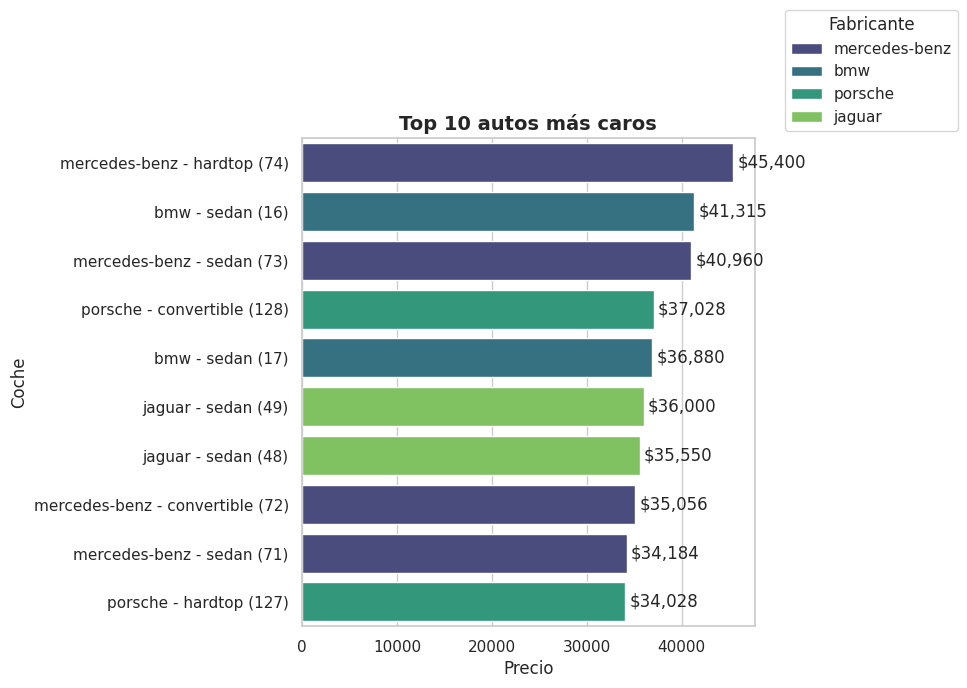

In [20]:

# 3.3 Top 10 automóviles más caros
# Orden descendente real + etiquetas de precio


# Ordenamos el dataframe por precio (descendente)

autos_top10 = (
    cars_df
    .sort_values(by="price", ascending=False)
    .head(10)
    .copy()
)

# Forzamos unicidad agregando índice
autos_top10["auto"] = (
    autos_top10["make"] + " - " +
    autos_top10["body_style"] +
    " (" + autos_top10.index.astype(str) + ")"
)

# Orden visual correcto (mayor arriba)
autos_top10 = autos_top10.sort_values("price", ascending=False)

plt.figure(figsize=(10,6))

ax = sns.barplot(
    data=autos_top10,
    x="price",
    y="auto",
    hue="make",
    palette="viridis"   # el hue me daba error
)

plt.title("Top 10 autos más caros")
plt.xlabel("Precio")
plt.ylabel("Coche")
plt.legend(title="Fabricante", bbox_to_anchor=(1.05,1))

# Creamos las 10 etiquetas
for i, price in enumerate(autos_top10["price"]):
    ax.text(
        price + autos_top10["price"].max()*0.01,
        i,
        f"${price:,.0f}",
        va="center"
    )

plt.tight_layout()
plt.show()

## **Análisis:**

El gráfico muestra una alta concentración de fabricantes premium dentro del segmento de precios más elevados, unicamente aparcen Mercedes-Benz, BMW, Porsche y Jaguar. La distribución no es uniforme: Mercedes-Benz domina varias posiciones dentro del top 10, lo que sugiere una mayor frecuencia de modelos de alto valor en el dataset. Además, los precios decrecen de manera relativamente gradual, sin saltos abruptos, lo que indica que el segmento de lujo tiene una estructura de precios escalonada en vez de dispersa. La presencia repetida de ciertas marcas sugiere que el fabricante es una variable categórica con fuerte poder explicativo sobre el precio.

De nuevo, esto es coherente: las marcas pertenecen al segmento premium o deportivo, caracterizado por motores grandes de alto desempeño y acabados de lujo. Este patrón confirma que la variable make (fabricante) tiene una relación directa con el posicionamiento de mercado y, por lo tanto es una variable relevante en modelos predictivos de precio.


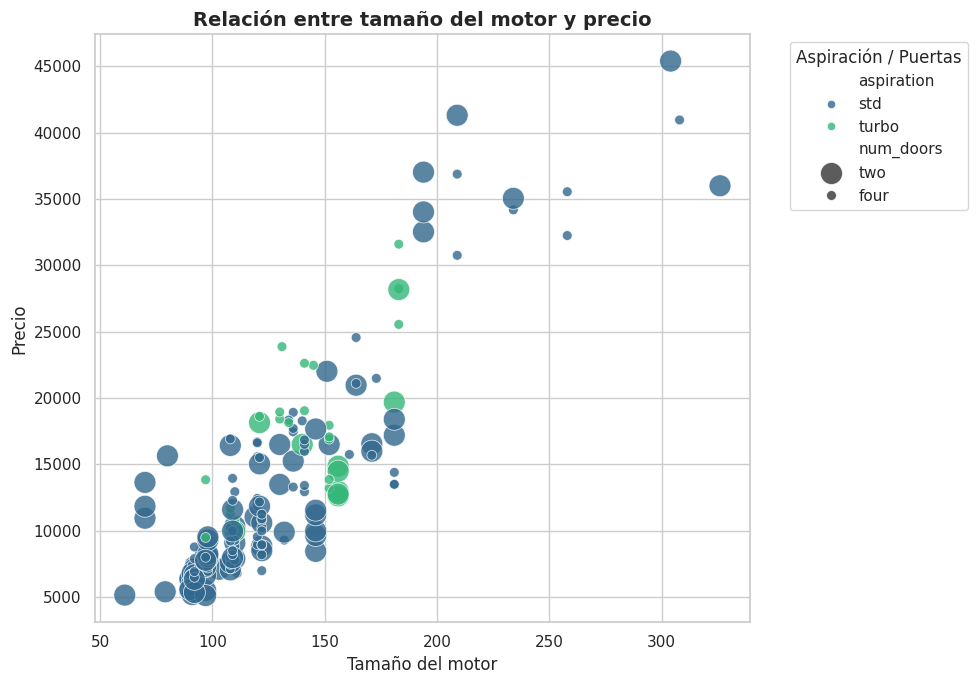

In [21]:
# 3.4 Scatter plot profesional

# Trabajamos con una copia por seguridad
autos_disp = cars_df.copy()

# Eliminamos posibles faltantes en variables clave
autos_disp = autos_disp.dropna(subset=["engine_size", "price", "aspiration", "num_doors"])


plt.figure(figsize=(10,7))

sns.scatterplot(
    data=autos_disp,
    x="engine_size",
    y="price",
    hue="aspiration",          # Color segun aspiración
    size="num_doors",       # Tamaño según puertas
    sizes=(50, 250),           # Rango visual de tamaños
    palette="viridis",
    alpha=0.8
)

plt.title("Relación entre tamaño del motor y precio", fontsize=14)
plt.xlabel("Tamaño del motor")
plt.ylabel("Precio")
plt.legend(title="Aspiración / Puertas", bbox_to_anchor=(1.05,1))

plt.tight_layout()
plt.show()

### **Análisis**

El diagrama de dispersión muestra una relación positiva clara entre el tamaño del motor y el precio, evidenciada por una tendencia ascendente en los puntos. A medida que aumenta engine_size, el precio tiende a incrementarse, evidenciando una correlación lineal moderadamente fuerte. Además, se observa mayor dispersión en motores grandes, indicando mas variabilidad en precios dentro del segmento alto. Los vehículos con aspiración turbo se concentran principalmente en rangos medios-altos de tamaño y precio, mientras que el tamaño de los puntos sugiere que muchos de los autos más costosos corresponden a configuraciones de dos puertas, lo que podría asociarse con segmentos deportivos.

De nuevo este patrón es coherente: motores más grandes implican mayor potencia, más cilindros y mayor costo de fabricación, lo que impacta directamente el precio final. Los autos turbo suelen posicionarse en gamas de desempeño superior y los modelos de dos puertas frecuentemente corresponden a deportivos, reforzando la asociación entre alto rendimiento y precios elevados. Este comportamiento respalda que engine_size sea una variable predictora clave en un modelo de regresión para estimar el precio de un automóvil.

4. Genera un mapa de calor de la matriz de correlación entre las variables numéricas del conjunto de datos, mostrando los valores de correlación en cada celda.
* ¿Cuáles son las tres variables más correlacionadas con el precio?

In [22]:

display(num_cols)

Index(['symboling', 'normalized_losses', 'wheel_base', 'length', 'width',
       'height', 'curb_weight', 'num_cylinders', 'engine_size', 'bore',
       'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg',
       'highway_mpg', 'price'],
      dtype='object')

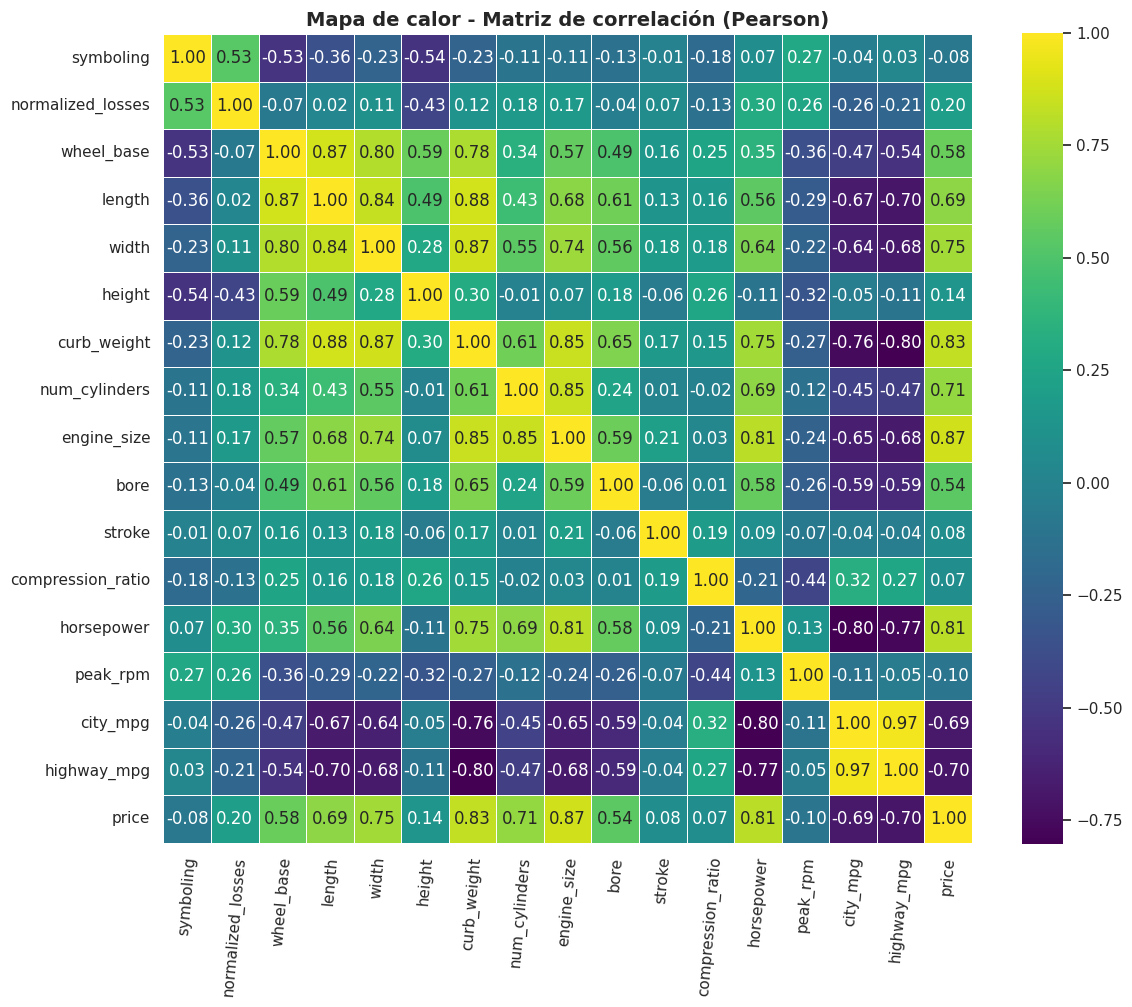

In [23]:
# Matriz de correlacion

matriz_correlacion = cars_df[num_cols].corr(method="pearson")

plt.figure(figsize=(12,10))

sns.heatmap(
    matriz_correlacion,
    annot=True,          # Muestra valores en cada celda
    fmt=".2f",           # Dos decimales
    cmap="viridis",      # Nuestra línea visual
    linewidths=0.5,
    square=True
)

plt.title("Mapa de calor - Matriz de correlación (Pearson)", fontsize=14)
plt.xticks(rotation=85)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()


## **Análisis:**

Las tres variables mas relacionadas con precios son:

1. engine_siza (0.87)
2. curb_weight (0.83)
3. horsepawer (0.81)

# Ingeniería de características

En el análisis de correlación se observa que existen muchos pares de variables altamente correlacionadas, lo que puede afectar el desempeño de los modelos de regresión. PCA resulta útil no solo para reducir la dimensionalidad, sino también porque los componentes principales son ortogonales entre sí, es decir, tienen correlación cero, evitando problemas de multicolinealidad. Esto lo podrás comprobrar más adelante.

5. Realiza las siguientes operaciones de ingeniería de características en las variables numéricas:
* Aplica `SimpleImputer` para tratar los valores faltantes, justificando la estrategia de imputación seleccionada.
* Considera `price` como la variable objetivo y guárdala en `y`. Separa los predictores numéricos en `X`. Con base en estos datos, ¿cuántos componentes principales se generarán al aplicar PCA?
* Escala los valores de `X` para que todas las variables contribuyan equitativamente y ninguna domine el análisis por tener una escala mayor.

In [28]:

# 1. Lo primero es ver que variables faltan y eso ya lo vimos son 6 con los siguientes porcentajes
display(missing_df)


,Porcentaje de Faltantes (%)
normalized_losses,20.00000
stroke,1.95122
price,1.95122
bore,1.95122
horsepower,0.97561
peak_rpm,0.97561
make,0.00000
fuel_type,0.00000
aspiration,0.00000
symboling,0.00000


In [29]:
# 2. Como price es la variable objetivo prefiero eliminar esas filas esas filas (son pocas)
# Me baso en que si intento predecir esa variable luego NO es buena práctica
# si vamos a modelar o evaluar después, porque inventamos la “verdad” que queremos predecir.
cars_df = cars_df.dropna(subset=["price"]).copy()

In [42]:
# 3. Revisamos de nuevo el skewness o la asimetria para ver como imputar
# Columnas con faltantes (excluyendo el target)
cols_faltantes = ["normalized_losses", "stroke", "bore", "horsepower", "peak_rpm"]

# Skewness (asimetría) de esas columnas
skew_cols = cars_df[cols_faltantes].skew(numeric_only=True).sort_values(key=lambda s: s.abs(), ascending=False)

display(skew_cols.to_frame("Skewness"))

,Skewness
horsepower,1.153019
normalized_losses,0.957177
stroke,-0.706744
peak_rpm,0.107729
bore,-0.032946


## **Análisis:**

Se analizaron las variables con faltantes, dentro de esa se determinó que para price, al ser la variable objetivo, es mejor eliminar ese porcentaje de los valores de esta forma no hacemos un sesgo en el data set.

Del resto de variables se analiza la simetria y se observa que 3 de ellas tienen un |skew| > 0.5 en ese sentido es recomendable imputar con la mediana (horsepower, normalized_looses, stroke), en el caso de las variables bore y peak_rpm al tener un valor cercano a cero, habla de simetria y por ende imputaremos con el promedio.

In [43]:
cols_mediana = ["horsepower", "normalized_losses", "stroke"]
cols_media = ["bore", "peak_rpm"]

imputador_mediana = SimpleImputer(strategy="median")
imputador_media = SimpleImputer(strategy="mean")

cars_df[cols_mediana] = imputador_mediana.fit_transform(cars_df[cols_mediana])
cars_df[cols_media] = imputador_media.fit_transform(cars_df[cols_media])

## **PCA** - Pasos Previos

In [44]:
# Como price es la variable objetivo no debe aparecer en los predictores

y = cars_df["price"]



In [45]:
# Ahora construimos X SOLO con variables numéricas.

X = cars_df.select_dtypes(include=["int64", "float64"]).drop(columns=["price"])
X.shape


(201, 16)

## **Respuesta:**

El número máximo de componentes principales generados por PCA es igual al número de variables numéricas utilizadas como predictores en X, ya que cada componente es una combinación lineal de dichas variables, en este caso 16.

### **Escalamos**

In [46]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
display(X_scaled)

array([[ 1.72504964, -0.17830627, -1.6851071 , ..., -0.24655573,
        -0.65224901, -0.54228772],
       [ 1.72504964, -0.17830627, -1.6851071 , ..., -0.24655573,
        -0.65224901, -0.54228772],
       [ 0.1271926 , -0.17830627, -0.71010295, ..., -0.24655573,
        -0.96439676, -0.689386  ],
       ...,
       [-1.47066444, -0.80268884,  1.70261919, ...,  0.80183295,
        -1.12047063, -1.13068086],
       [-1.47066444, -0.80268884,  1.70261919, ..., -0.6659112 ,
         0.12812034, -0.54228772],
       [-1.47066444, -0.80268884,  1.70261919, ...,  0.59215521,
        -0.96439676, -0.83648429]])

PCA está diseñado principalmente para variables numéricas y funciona encontrando combinaciones lineales de las variables originales que capturan la mayor varianza en los datos. Normalmente se recomienda eliminar las variables categóricas antes de aplicar PCA y luego concatenarlas nuevamente con los resultados de PCA si se desea.

6. Aplica `PCA` a los datos escalados para proyectarlos en el nuevo espacio de vectores.
* Asigna nombres descriptivos a los componentes principales en el dataframe resultante, utilizando la convención PC1, PC2, PC3, y así sucesivamente.
* Genera un mapa de calor con la matriz de correlaciones de los componentes principales para verificar que sean independientes entre sí.

In [49]:

# 6.1 PCA: proyectar datos escalados

# Creamos el objeto PCA
# Si no le pasamos el numero de componentes PCA calcula el máximo posible: min(n_muestras, n_features)

pca = PCA()

# 2) Ajustamos PCA y transformamos X_scaled al nuevo espacio
X_pca = pca.fit_transform(X_scaled)

# 3) Verificamos dimensiones: debe ser (n_filas, n_componentes)
display(f"Shape del X_scaled: {X_scaled.shape}")
display(f"Shape del X_pca: {X_pca.shape}")

'Shape del X_scaled: (201, 16)'

'Shape del X_pca: (201, 16)'

In [50]:
# 6.2 DataFrame con nombres PC1, PC2...

# Generamos nombres: PC1, PC2, ..., PC16

n_componentes = X_pca.shape[1]
nombres_componentes = [f"PC{i+1}" for i in range(n_componentes)]

# Creamos DataFrame final de PCA (con el mismo índice que cars_df para alinearlo)

df_pca = pd.DataFrame(X_pca, columns=nombres_componentes, index=cars_df.index)

display(df_pca.head())

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,PC15,PC16
0,-0.930510,-2.411113,-0.413765,1.447618,-1.842752,-1.114120,0.544614,0.120306,-0.987756,-0.400775,0.398108,-0.239496,0.313435,0.395930,0.220426,-0.121899
1,-0.930510,-2.411113,-0.413765,1.447618,-1.842752,-1.114120,0.544614,0.120306,-0.987756,-0.400775,0.398108,-0.239496,0.313435,0.395930,0.220426,-0.121899
2,0.663065,-1.418976,0.948507,1.159657,1.946084,0.709478,-0.079956,1.211794,-1.010173,-1.255717,0.457557,0.662562,-0.188131,-0.025981,0.117626,0.103668
3,-0.368165,-0.943259,0.439065,-1.435178,-0.194429,0.848361,-0.009683,0.443403,0.236102,0.152987,-0.015822,-0.016985,0.082741,-0.391568,-0.022975,-0.039800
4,1.182960,-1.844881,0.198397,-0.946152,0.230255,0.911750,-0.190276,0.871345,0.021616,-0.494053,-0.355337,-0.297454,0.078131,0.119802,-0.167112,-0.008426


Previo a hacer el análisis: Los componentes principales están construidos para ser ortogonales o sea a 90°, En la práctica, eso implica que sus correlaciones deberían ser aprox 0 (o extremadamente cercanas a 0 por error numérico)

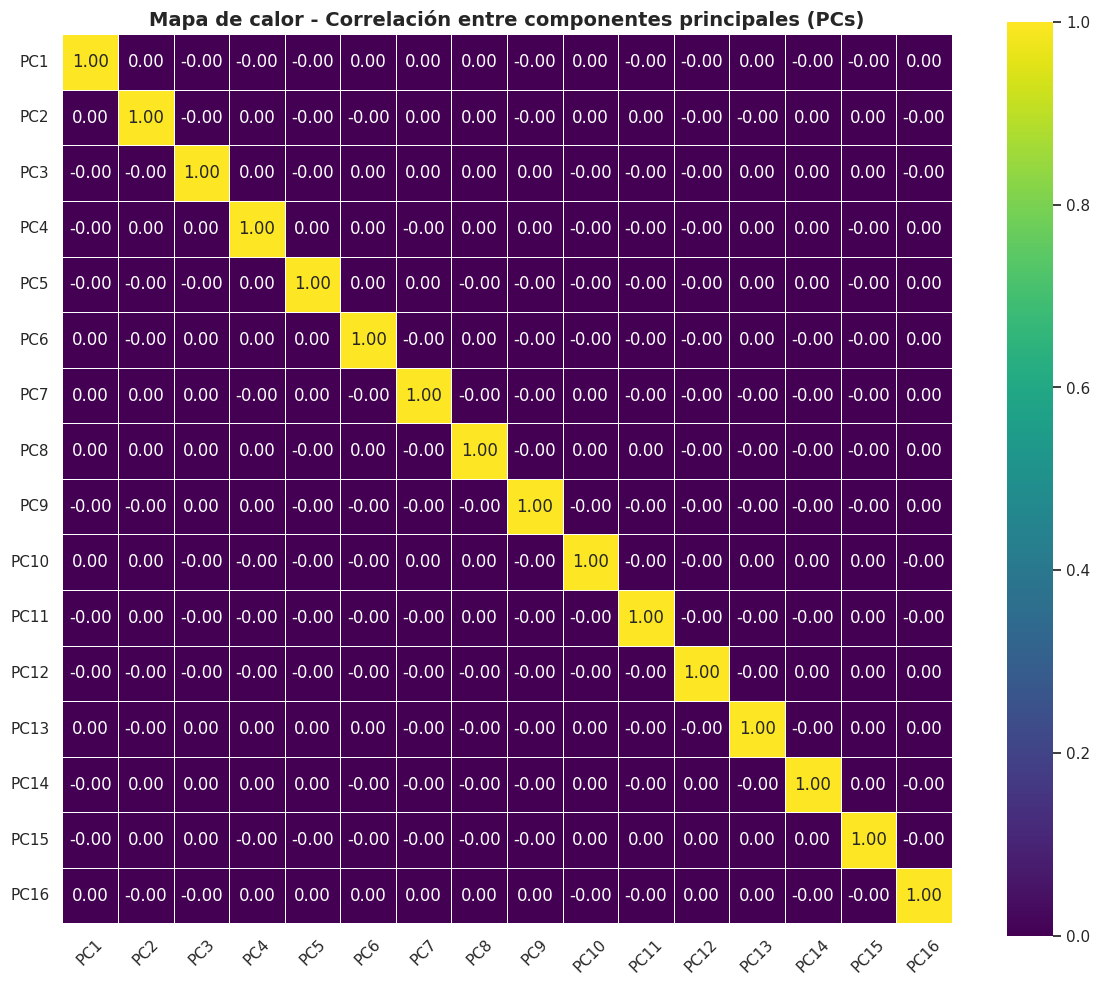

In [51]:
# 6.3 Correlación entre componentes (debe ser casi 0)

# Matriz de correlación entre PCs
corr_pcs = df_pca.corr()

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_pcs,
    annot=True,
    fmt=".2f",
    cmap="viridis",
    linewidths=0.5,
    square=True
)

plt.title("Mapa de calor - Correlación entre componentes principales (PCs)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

7. Obtén el porcentaje de varianza explicada por cada componente.
* Grafica la curva de varianza acumulada para determinar el número mínimo de componentes principales que explican más del 90% de la varianza total.

In [57]:
# pca ya fue ajustado antes con fit_transform
varianza_explicada = pca.explained_variance_ratio_

# Convertimos a porcentaje
varianza_pct = varianza_explicada * 100

# Creamos la acumulada
varianza_acumulada_pct = np.cumsum(varianza_pct)

# Creamos DataFrame para visualizar mejor
df_varianza = pd.DataFrame({
    "Componente": [f"PC{i}" for i in range(1, len(varianza_pct)+1)],
    "Varianza explicada (%)": varianza_pct,
    "Varianza acumulada (%)": varianza_acumulada_pct
})

# Redondeamos a 2 decimales
df_varianza = df_varianza.round(2)

df_varianza
df_varianza.style.background_gradient(cmap="viridis")

,Componente,Varianza explicada (%),Varianza acumulada (%)
0,PC1,44.680000,44.680000
1,PC2,17.980000,62.660000
2,PC3,8.670000,71.330000
3,PC4,6.370000,77.700000
4,PC5,5.720000,83.420000
5,PC6,4.890000,88.310000
6,PC7,3.140000,91.450000
7,PC8,2.670000,94.120000
8,PC9,1.930000,96.040000
9,PC10,1.540000,97.580000


<Figure size 800x600 with 0 Axes>

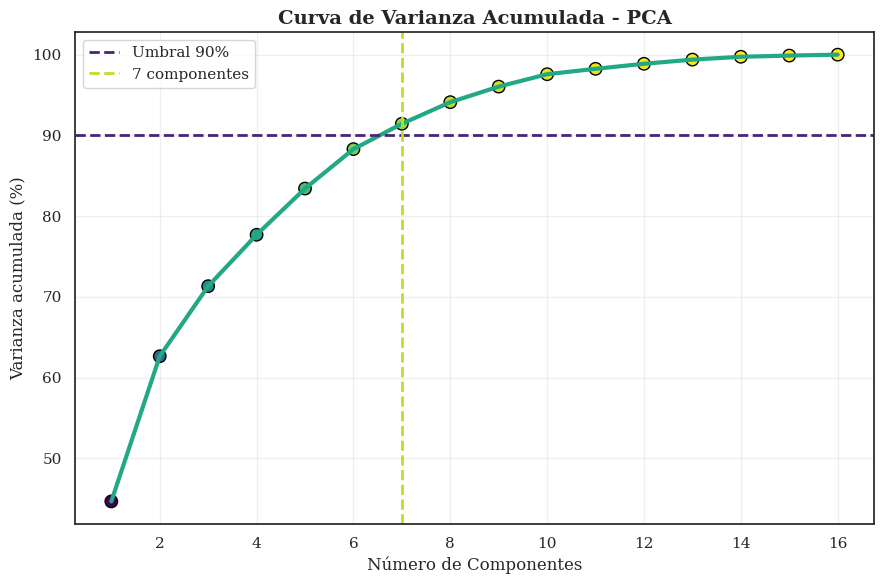

In [71]:
# Ahora graficamos esa Varianza


plt.figure(figsize=(8,6))

# Número de componentes
componentes = range(1, len(varianza_acumulada_pct)+1)

# Crear mapa de colores viridis
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(varianza_acumulada_pct)))

plt.figure(figsize=(9,6))

# Línea principal
plt.plot(componentes, varianza_acumulada_pct,
         color=plt.cm.viridis(0.6),
         linewidth=3)

# Puntos individuales con gradiente
plt.scatter(componentes, varianza_acumulada_pct,
            c=varianza_acumulada_pct,
            cmap="viridis",
            s=80,
            edgecolor="black")

# Línea horizontal 90%
plt.axhline(y=90,
            color=plt.cm.viridis(0.1),
            linestyle="--",
            linewidth=2,
            label="Umbral 90%")

# Encontrar componente mínimo >90%
n_componentes_90 = np.argmax(varianza_acumulada_pct >= 90) + 1

plt.axvline(x=n_componentes_90,
            color=plt.cm.viridis(0.9),
            linestyle="--",
            linewidth=2,
            label=f"{n_componentes_90} componentes")

plt.xlabel("Número de Componentes", fontsize=12)
plt.ylabel("Varianza acumulada (%)", fontsize=12)
plt.title("Curva de Varianza Acumulada - PCA", fontsize=14)
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


### **Análisis:**

Desde el análisis de datos se puede entender entonces que con 7 componentes de los 16 podemos conservar entonces el 91.45% de los datos, ya que concentran el 91% de las varianzas.

8. Imprime la información de los componentes seleccionados (cargas o pesos de las variables originales) para interpretar qué variables contribuyen más a cada componente principal.
* Dibuja un diagrama de barras que muestre qué variables originales aportan más al primer componente principal (PC1), para visualizar su influencia relativa.

In [74]:
# Construir tabla con las cargas y nombres

loadings = pd.DataFrame(
    pca.components_,
    columns=X.columns,
    index=[f"PC{i}" for i in range(1, len(X.columns)+1)]
)

loadings.head(7)

,symboling,normalized_losses,wheel_base,length,width,height,curb_weight,num_cylinders,engine_size,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg
PC1,-0.100203,0.016018,0.300357,0.339033,0.332751,0.118978,0.361151,0.242357,0.329124,0.259709,0.051955,0.016488,0.300431,-0.091698,-0.303642,-0.317633
PC2,-0.403741,-0.334991,0.257461,0.132234,0.066986,0.414643,0.022610,-0.104282,-0.082191,0.003241,0.032844,0.363908,-0.277399,-0.358700,0.254189,0.206636
PC3,0.262176,0.307270,-0.031160,-0.044398,0.108076,-0.286688,0.081537,0.190710,0.205338,-0.153790,0.511481,0.477598,0.009780,-0.257257,0.198627,0.189104
PC4,-0.062363,-0.321041,-0.224365,-0.181946,-0.132730,-0.169875,-0.025024,0.565197,0.305432,0.005782,-0.435505,-0.033582,0.139320,-0.318281,0.148480,0.127188
PC5,-0.361682,-0.350219,0.005098,-0.063655,-0.029844,0.014786,-0.046714,0.257887,0.114389,-0.407512,0.550342,-0.250048,0.097117,0.344399,0.007847,-0.001455
PC6,-0.135197,0.507559,0.182498,0.093171,0.111337,0.231407,0.014908,0.333146,-0.031995,-0.501548,-0.388219,0.095265,-0.082577,0.269068,0.094355,0.066951
PC7,0.219896,-0.389738,-0.136727,-0.002064,0.082287,0.050637,0.076263,-0.020088,-0.027829,0.033931,-0.158240,0.618516,0.207682,0.559286,0.001959,-0.005731


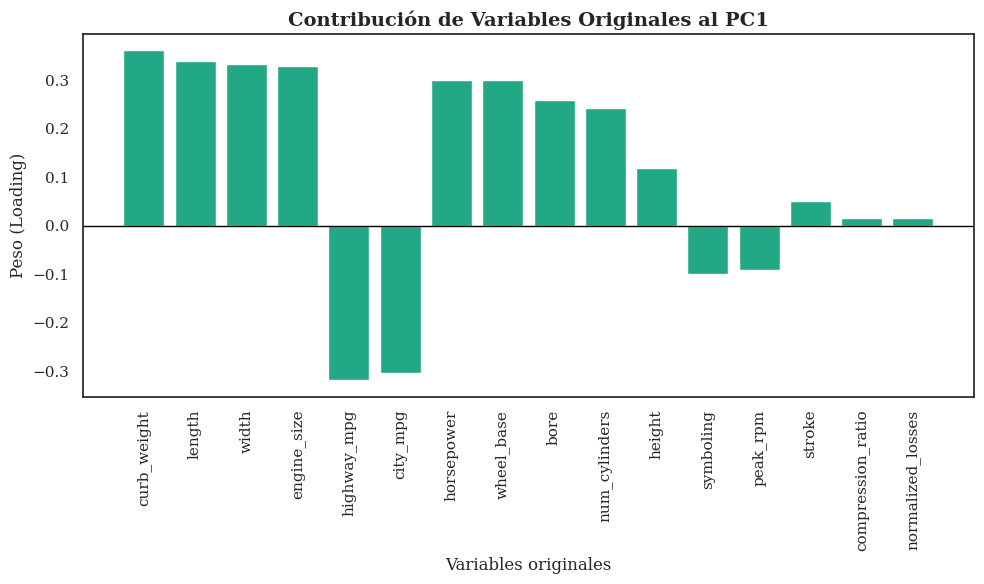

In [75]:
# En PCA nos importa principalmente la magnitud (|loading|) no el signo.

# Tomamos solo PC1
pc1_loadings = loadings.loc["PC1"]

# Ordenamos por magnitud absoluta (aunque luego representemos con +y-)
pc1_sorted = pc1_loadings.reindex(
    pc1_loadings.abs().sort_values(ascending=False).index
)

plt.figure(figsize=(10,6))

plt.bar(pc1_sorted.index,
        pc1_sorted.values,
        color=plt.cm.viridis(0.6))

plt.xticks(rotation=90)
plt.title("Contribución de Variables Originales al PC1")
plt.ylabel("Peso (Loading)")
plt.xlabel("Variables originales")

plt.axhline(0, color="black", linewidth=1)
plt.tight_layout()
plt.show()

### **Análisis**

El primer componente principal representa una dimensión estructural asociada al tamaño y potencia del vehículo. Las variables relacionadas con masa y desempeño mecánico presentan cargas positivas altas, mientras que las variables de eficiencia de combustible presentan cargas negativas fuertes. Esto sugiere que PC1 distingue entre vehículos grandes y potentes frente a vehículos pequeños y eficientes

COMENTARIO PERSONAL:
En este punto recuerdo que habia una alta correlación entre city_mpg y highway_mpg, tal vez hubiese sido bueno trabajar solo con alguna y asi hacer de mi dataframe mas pequeño

9. Codifica las variables categóricas mediante *One-Hot Encoding* y utiliza el parámetro `drop='first'` para evitar problemas de multicolinealidad entre las variables dummy generadas.

In [80]:
# Ya las catrgoricas estaban definidas

# Encoder: drop='first' evita multicolinealidad (dummy trap)
encoder = OneHotEncoder(drop="first", sparse_output=False, handle_unknown="ignore")

# Transformamos las categóricas de cars_df
matriz_dummies = encoder.fit_transform(cars_df[cat_cols])

# Lo convertimos a DataFrame con nombres de columnas
df_dummies = pd.DataFrame(
    matriz_dummies,
    columns=encoder.get_feature_names_out(cat_cols),
    index=cars_df.index
)

display(df_dummies.head())

,make_audi,make_bmw,make_chevrolet,make_dodge,make_honda,make_isuzu,make_jaguar,make_mazda,make_mercedes-benz,make_mercury,...,engine_type_ohcf,engine_type_ohcv,engine_type_rotor,fuel_system_2bbl,fuel_system_4bbl,fuel_system_idi,fuel_system_mfi,fuel_system_mpfi,fuel_system_spdi,fuel_system_spfi
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [82]:
# Variables numéricas (sin las categóricas originales)
df_numericas = cars_df.drop(columns=cat_cols)

# Dataset final listo para modelado (numéricas + dummies)
df_modelo = pd.concat([df_numericas, df_dummies], axis=1)

display(df_modelo.head())
display(df_modelo.shape)

,symboling,normalized_losses,wheel_base,length,width,height,curb_weight,num_cylinders,engine_size,bore,...,engine_type_ohcf,engine_type_ohcv,engine_type_rotor,fuel_system_2bbl,fuel_system_4bbl,fuel_system_idi,fuel_system_mfi,fuel_system_mpfi,fuel_system_spdi,fuel_system_spfi
0,3,115.0,88.6,168.8,64.1,48.8,2548,4,130,3.47,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,3,115.0,88.6,168.8,64.1,48.8,2548,4,130,3.47,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1,115.0,94.5,171.2,65.5,52.4,2823,6,152,2.68,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
3,2,164.0,99.8,176.6,66.2,54.3,2337,4,109,3.19,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,2,164.0,99.4,176.6,66.4,54.3,2824,5,136,3.19,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


(201, 60)

10. Conjunta, en un dataframe, las valores proyectados en los componentes seleccionados (mínimo), las transformaciones obtenidas de las variables categóricas y la variable de salida.
* Almacena el dataframe resultante en archivo.

In [84]:
# Primero los componentes que necesitamos que representan el 90% de la varianza

n_componentes_90 = 7

df_pca_seleccionado = df_pca.iloc[:, :n_componentes_90]
df_pca_seleccionado.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7
0,-0.930510,-2.411113,-0.413765,1.447618,-1.842752,-1.114120,0.544614
1,-0.930510,-2.411113,-0.413765,1.447618,-1.842752,-1.114120,0.544614
2,0.663065,-1.418976,0.948507,1.159657,1.946084,0.709478,-0.079956
3,-0.368165,-0.943259,0.439065,-1.435178,-0.194429,0.848361,-0.009683
4,1.182960,-1.844881,0.198397,-0.946152,0.230255,0.911750,-0.190276


In [86]:
#Unimos todo

df_final = pd.concat(
    [df_pca_seleccionado, df_dummies, y],
    axis=1
)

display(df_final.head())
df_final.shape

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,make_audi,make_bmw,make_chevrolet,...,engine_type_ohcv,engine_type_rotor,fuel_system_2bbl,fuel_system_4bbl,fuel_system_idi,fuel_system_mfi,fuel_system_mpfi,fuel_system_spdi,fuel_system_spfi,price
0,-0.930510,-2.411113,-0.413765,1.447618,-1.842752,-1.114120,0.544614,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,13495.0
1,-0.930510,-2.411113,-0.413765,1.447618,-1.842752,-1.114120,0.544614,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,16500.0
2,0.663065,-1.418976,0.948507,1.159657,1.946084,0.709478,-0.079956,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,16500.0
3,-0.368165,-0.943259,0.439065,-1.435178,-0.194429,0.848361,-0.009683,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,13950.0
4,1.182960,-1.844881,0.198397,-0.946152,0.230255,0.911750,-0.190276,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,17450.0


(201, 51)

In [87]:
# Guardamos

df_final.to_csv(
    "/content/drive/MyDrive/01 Analisis de Datos/ACTIVIDAD 7/dataset_modelado_pca_90varianza.csv",
    index=False
)